# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
# Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 flask==3.0.3 streamlit==1.43.2 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 58.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.10.2 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.34.0 which is incompatible.


### Code explanation and observations

**What this code does**
- Installs the exact library versions required for data analysis, model building, serialization, backend API creation, frontend UI creation, and Hugging Face deployment.
- Version pinning helps the notebook run consistently across Colab, local notebooks, and Hugging Face Spaces.

**Observations**
- The installation cell completed successfully.
- After running this cell in Colab, the runtime should be restarted once so the pinned package versions are loaded correctly before executing the remaining cells.

**Note:**

- After running the installation cell, restart the notebook kernel/runtime and run all cells sequentially.
- The Hugging Face upload cells use a secure token prompt or the `HF_TOKEN` environment variable. The token is not hard-coded in this notebook.

In [ ]:
import os
import io
import json
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

from xgboost import XGBRegressor

# Serialization and deployment
import joblib
import requests
from getpass import getpass
from huggingface_hub import login, HfApi

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

### Code explanation and observations

**What this code does**
- Imports the libraries used throughout the project.
- `pandas` and `numpy` are used for data handling.
- `matplotlib` and `seaborn` are used for visualization.
- Scikit-learn utilities are used for train-test split, preprocessing, pipelines, metrics, and Random Forest modeling.
- XGBoost is imported for gradient boosting regression.
- `joblib` is used to save the final model bundle.
- Hugging Face Hub utilities are imported to create and upload deployment files.

**Observations**
- This is a setup cell. It does not produce a model result by itself.
- Successful execution confirms that the notebook environment has all required packages available.

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Code explanation and observations

**What this code does**
- Mounts Google Drive in Colab so the dataset can be read from the user’s Drive path.

**Observations**
- The output shows that Google Drive was mounted successfully.
- If this notebook is run outside Colab, this cell can be skipped and the dataset path should be changed to the local file path.

In [ ]:
# Load the dataset
data = pd.read_csv("/content/drive/My Drive/Data Science Course/Model Deployment/assignment/SuperKart.csv")

# Create a working copy
df = data.copy()

# Display first five rows
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


### Code explanation and observations

**What this code does**
- Reads `SuperKart.csv` into a pandas DataFrame.
- Creates a working copy named `df` so the original loaded data remains available if needed.
- Displays the first few rows to validate that the file loaded correctly and the columns match the problem description.

**Observations**
- The dataset loaded correctly with product, store, and sales-related fields.
- The target column is `Product_Store_Sales_Total`, which is the value the model will predict.
- The preview confirms that both numerical and categorical variables are present, so preprocessing is required before modeling.

# **Data Overview**

In [ ]:
# Shape of the dataset
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns in the dataset.")

# Dataset information
df.info()

There are 8763 rows and 12 columns in the dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.

### Code explanation and observations

**What this code does**
- Prints the number of rows and columns in the dataset.
- Uses `df.info()` to inspect column names, non-null counts, and data types.

**Observations**
- The dataset has **8,763 rows** and **12 columns**.
- There are **no missing values** in any column based on the non-null counts.
- The dataset contains **5 numerical columns** and **7 categorical/object columns**.
- Since several columns are categorical, they must be encoded before being passed into machine learning models.

In [ ]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


### Code explanation and observations

**What this code does**
- Generates summary statistics for numerical columns using `describe().T`.
- Shows count, mean, standard deviation, minimum, quartiles, and maximum values.

**Observations**
- Average `Product_Store_Sales_Total` is about **3,464**, with values ranging from **33** to **8,000**.
- Average `Product_MRP` is about **147**, and it ranges from **31** to **266**.
- `Product_Allocated_Area` has a small average value but a relatively wide range, suggesting some products receive much more allocated store area than others.
- `Store_Establishment_Year` ranges from **1987** to **2009**, so converting it to store age is more useful for modeling than using the year directly.

In [ ]:
# Summary statistics for categorical columns
df.describe(include="object").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


### Code explanation and observations

**What this code does**
- Generates summary statistics for categorical columns.
- Shows the number of unique categories, most frequent category, and its frequency.

**Observations**
- `Product_Id` has **8,763 unique values**, so it should not be used directly as a high-cardinality identifier in the model.
- `Product_Sugar_Content` has inconsistent category labeling because it has 4 unique values, including a duplicate meaning such as `reg` and `Regular`.
- `Product_Type` has **16 categories**, with **Fruits and Vegetables** being the most common.
- `Store_Id`, `Store_Size`, `Store_Location_City_Type`, and `Store_Type` have a small number of categories and are useful for one-hot encoding.

In [ ]:
# Checking missing values
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_values

,Missing Values,Percentage
Product_Id,0,0.0
Product_Weight,0,0.0
Product_Sugar_Content,0,0.0
Product_Allocated_Area,0,0.0
Product_Type,0,0.0
Product_MRP,0,0.0
Store_Id,0,0.0
Store_Establishment_Year,0,0.0
Store_Size,0,0.0
Store_Location_City_Type,0,0.0


### Code explanation and observations

**What this code does**
- Checks missing values in each column.
- Calculates both the number and percentage of missing values.

**Observations**
- There are **0 missing values** across all columns.
- No imputation is required before modeling.
- The preprocessing pipeline can focus on feature engineering, scaling, and encoding instead of missing-value treatment.

In [ ]:
# Checking duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### Code explanation and observations

**What this code does**
- Checks whether the dataset contains duplicate rows.

**Observations**
- The dataset has **0 duplicate rows**.
- No rows need to be removed for duplication.
- This is a clean starting point for EDA and modeling.

### Initial observations

- The dataset contains **8,763 records** and **12 columns**.
- The target variable is `Product_Store_Sales_Total`.
- There are **no missing values** and **no duplicate rows**, so the data quality is good for modeling.
- `Product_Id` is unique for every row and should not be used directly as a model feature; however, its prefix is useful for deriving `Product_Category`.
- `Product_Sugar_Content` has inconsistent values such as `reg` and `Regular`, so category standardization is required.
- The problem is a **supervised regression problem** because the target variable is continuous sales value.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

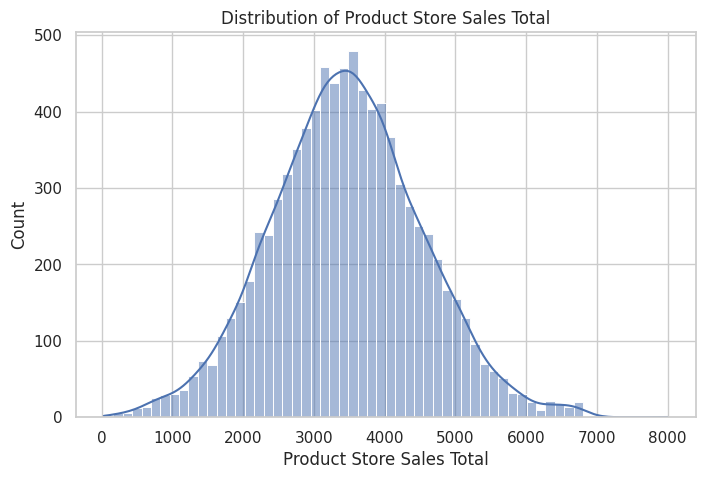

In [ ]:
# Target variable distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Product_Store_Sales_Total"], kde=True)
plt.title("Distribution of Product Store Sales Total")
plt.xlabel("Product Store Sales Total")
plt.ylabel("Count")
plt.show()

### Code explanation and observations

**What this code does**
- Plots the distribution of the target variable `Product_Store_Sales_Total`.
- Uses a histogram with a KDE curve to understand the overall sales pattern.

**Observations**
- The target variable is fairly spread out, with most observations concentrated around mid-range sales values.
- There are some high-sales observations, but the distribution is not extremely skewed.
- Since the target is continuous, this is a **regression problem**, not a classification problem.

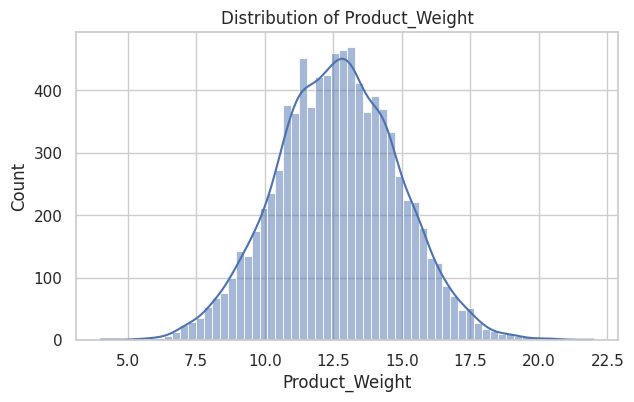

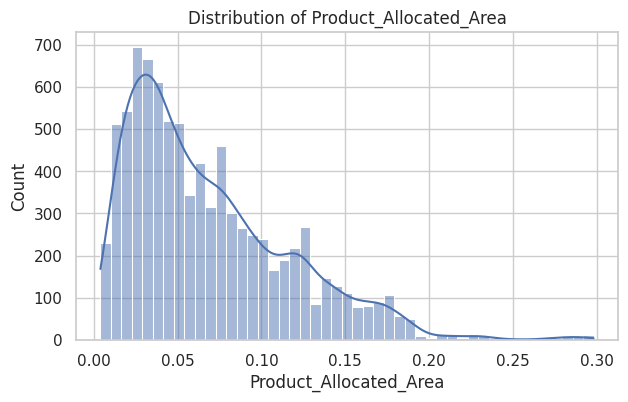

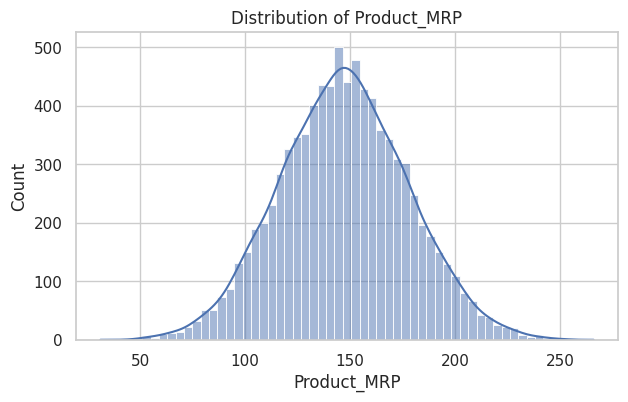

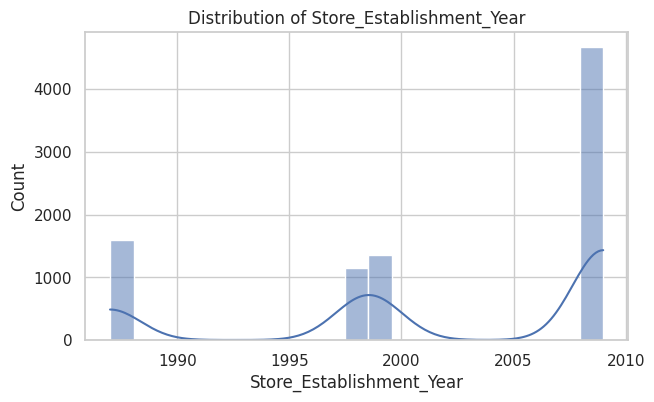

In [ ]:
# Numerical feature distributions
num_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Establishment_Year"]

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Code explanation and observations

**What this code does**
- Plots distributions of key numerical input variables.
- This helps understand the range, spread, and shape of each numerical feature.

**Observations**
- `Product_Weight` and `Product_MRP` are reasonably spread across their ranges.
- `Product_Allocated_Area` is right-skewed, meaning most products occupy smaller allocated areas while a few have larger allocation.
- `Store_Establishment_Year` has repeated values because stores belong to a limited number of establishment years.
- These numerical variables are scaled later so models receive them in a standardized format.

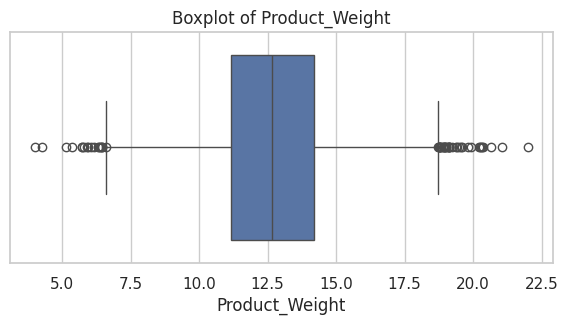

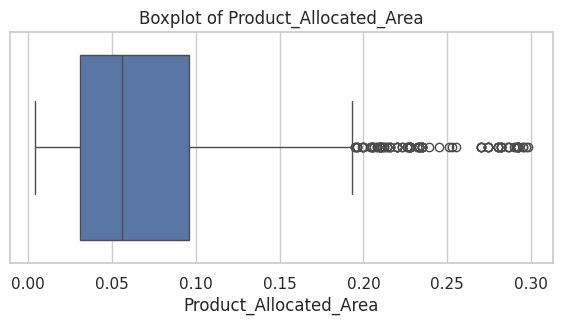

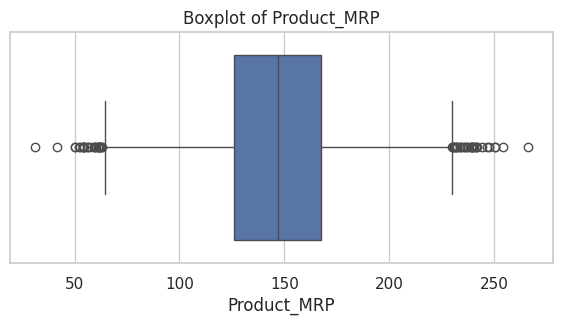

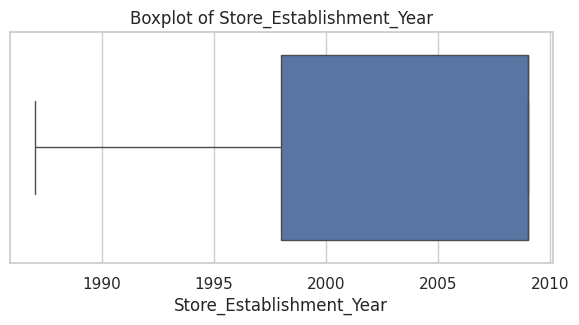

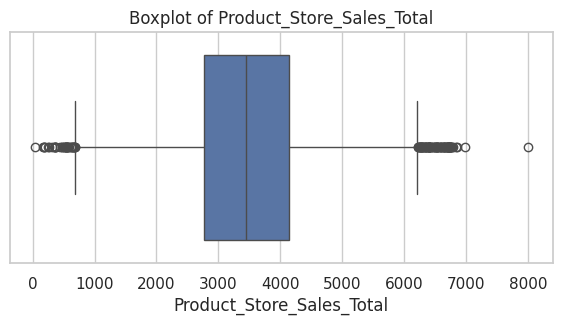

In [ ]:
# Boxplots to check outliers in numerical columns
for col in num_cols + ["Product_Store_Sales_Total"]:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Code explanation and observations

**What this code does**
- Creates boxplots for numerical variables and the target.
- Boxplots help detect outliers and compare value ranges.

**Observations**
- Some outliers are visible in `Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, and `Product_Store_Sales_Total`.
- The outliers do not appear to be invalid data; they likely represent legitimate products or stores.
- Tree-based models such as Random Forest and XGBoost are generally robust to outliers, so no aggressive outlier removal is performed.

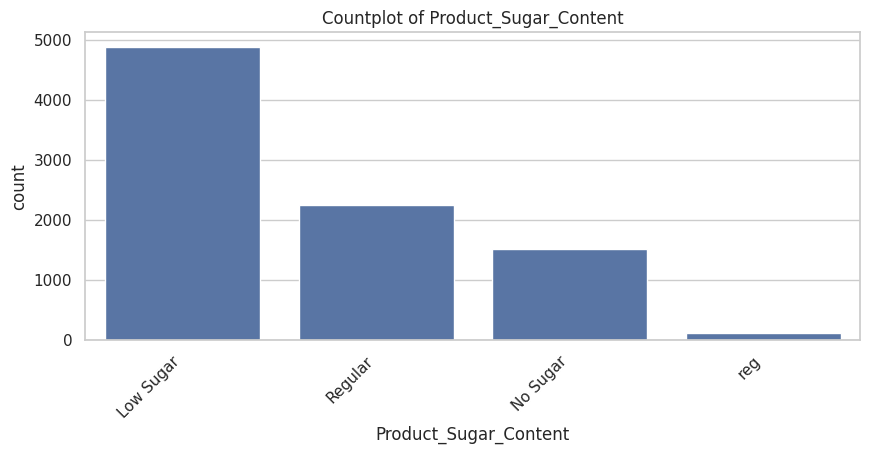

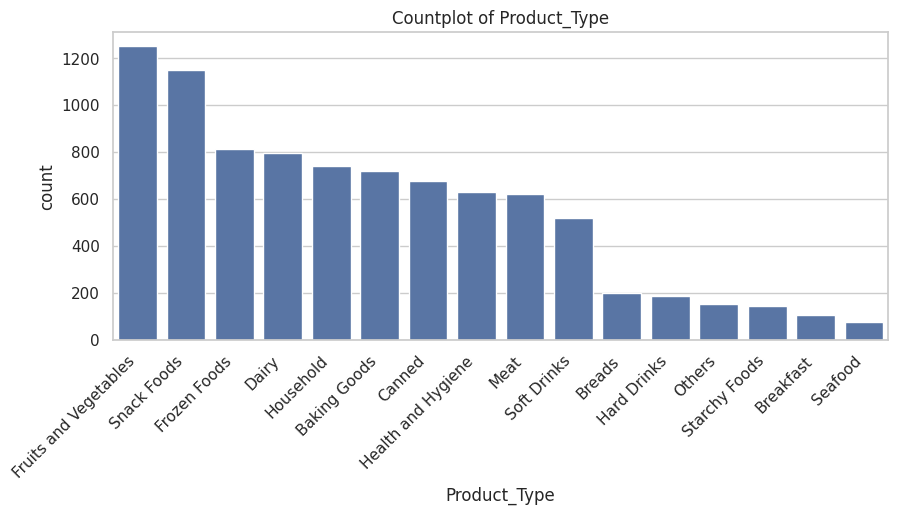

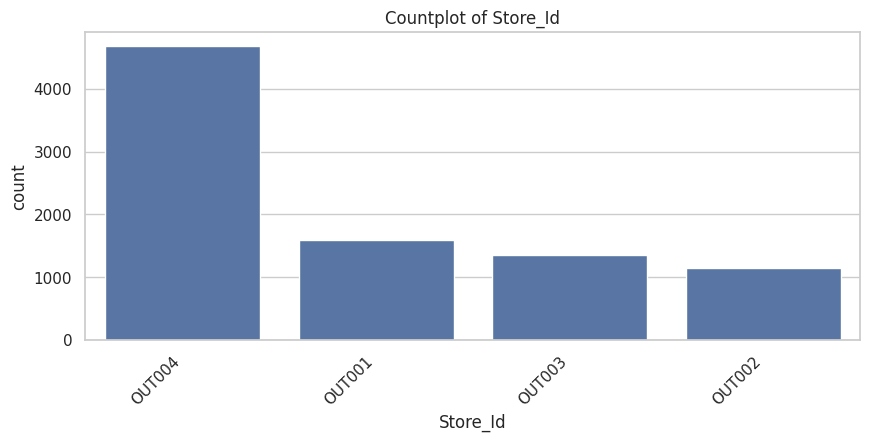

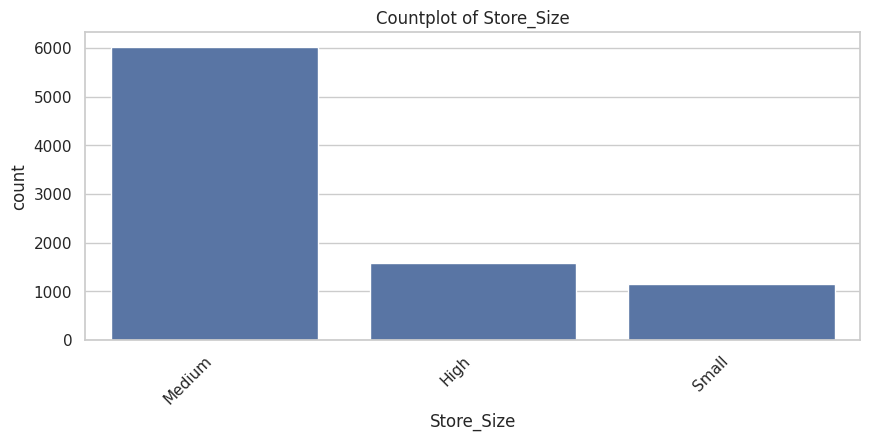

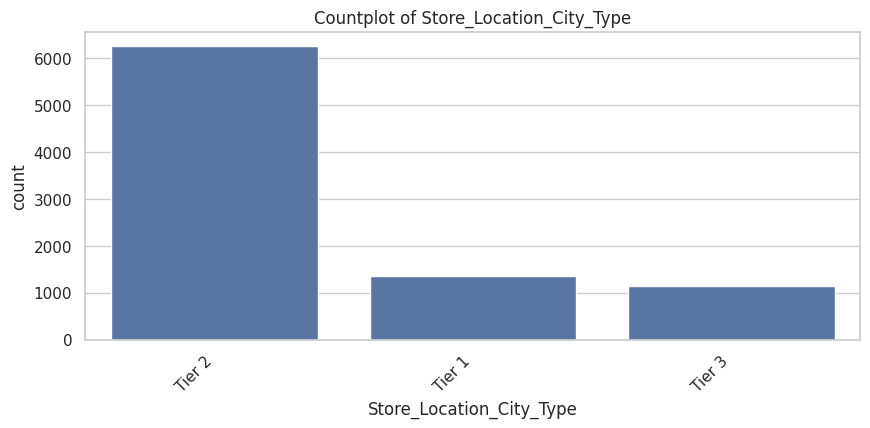

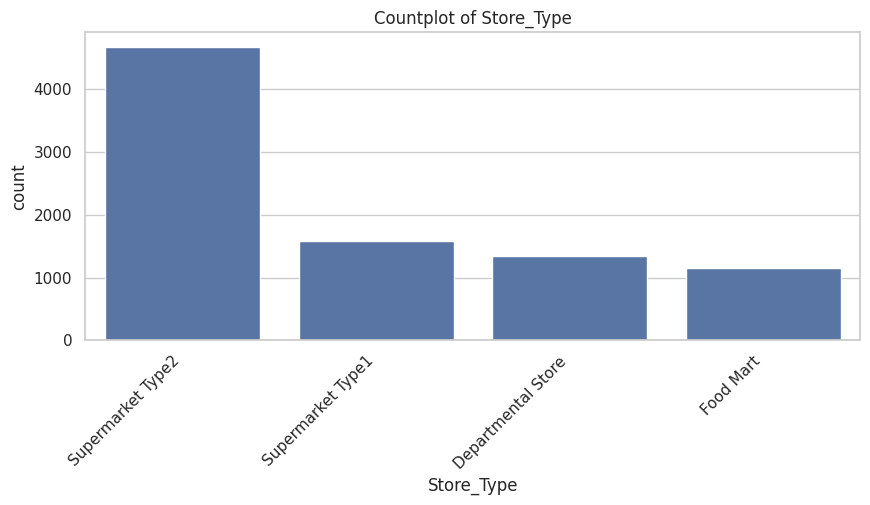

In [ ]:
# Categorical feature distributions
cat_cols = [
    "Product_Sugar_Content", "Product_Type", "Store_Id", "Store_Size",
    "Store_Location_City_Type", "Store_Type"
]

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.show()

### Code explanation and observations

**What this code does**
- Creates count plots for categorical variables.
- This shows how frequently each category appears in the dataset.

**Observations**
- `Low Sugar` is the most common sugar-content category.
- `Fruits and Vegetables`, `Snack Foods`, `Frozen Foods`, and `Dairy` are among the most frequent product types.
- Most records belong to **Medium** stores and **Tier 2** city locations.
- `Supermarket Type2` is the most common store type.
- Category imbalance is present, but one-hot encoding can still represent these categories effectively.

## Bivariate Analysis

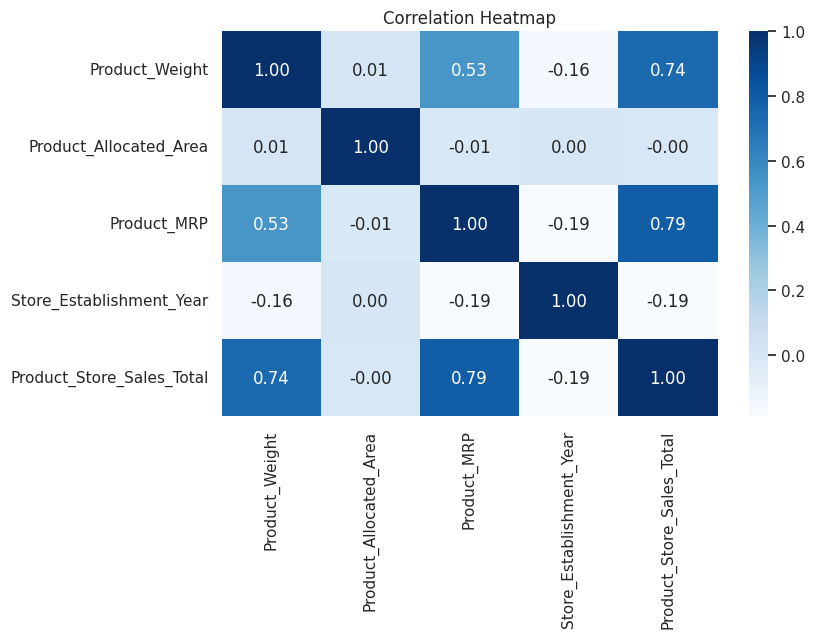

In [ ]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Code explanation and observations

**What this code does**
- Calculates correlations among numerical variables.
- Displays the correlations using a heatmap.

**Observations**
- `Product_MRP` has a strong positive correlation with sales, around **0.79**.
- `Product_Weight` also shows a strong positive relationship with sales, around **0.74**.
- `Product_Allocated_Area` has almost no linear correlation with sales.
- `Store_Establishment_Year` has a mild negative correlation with sales, which supports converting it into `Store_Age` for better interpretation.

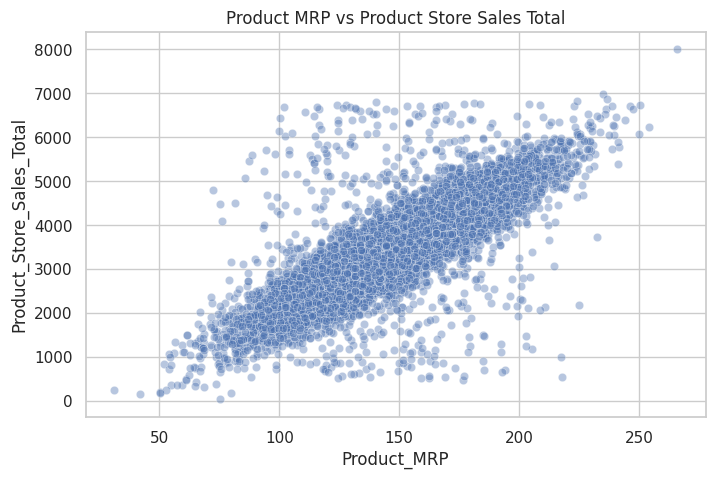

In [ ]:
# Relationship between MRP and sales
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Product_MRP", y="Product_Store_Sales_Total", alpha=0.4)
plt.title("Product MRP vs Product Store Sales Total")
plt.show()

### Code explanation and observations

**What this code does**
- Creates a scatterplot between `Product_MRP` and `Product_Store_Sales_Total`.
- This checks whether higher product price is associated with higher sales value.

**Observations**
- The plot shows a clear positive relationship between MRP and total sales.
- This confirms that `Product_MRP` is likely one of the most important predictors.
- The spread around the trend also shows that price alone is not enough; store and product attributes also matter.

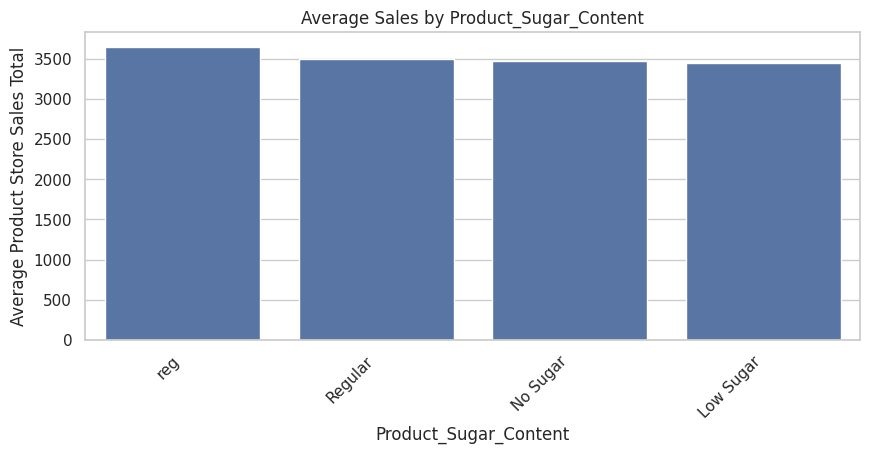

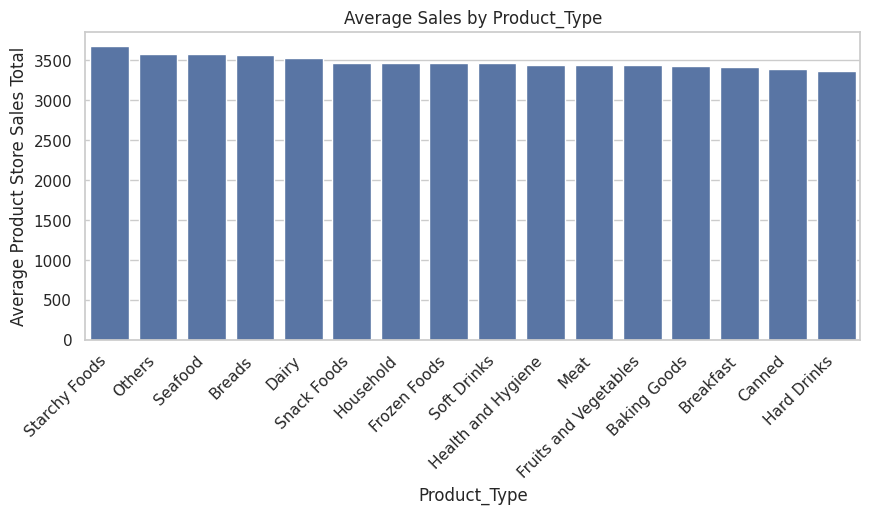

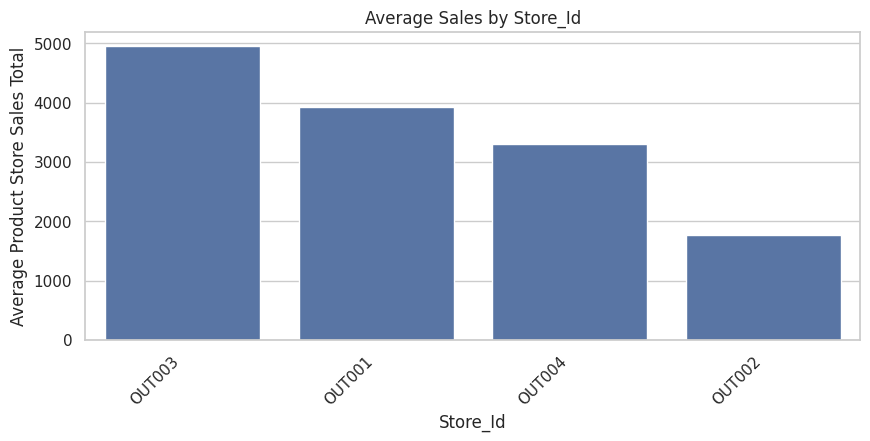

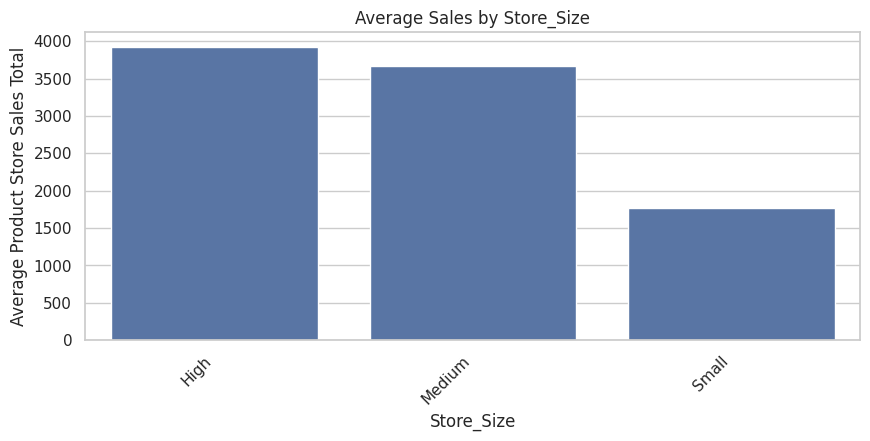

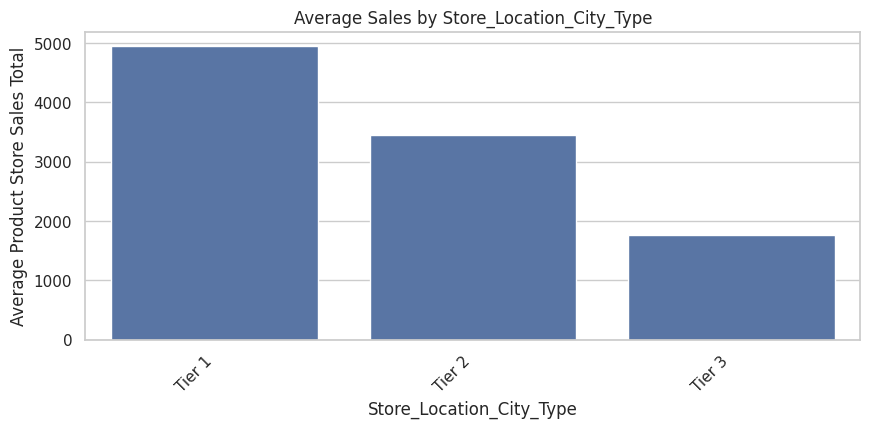

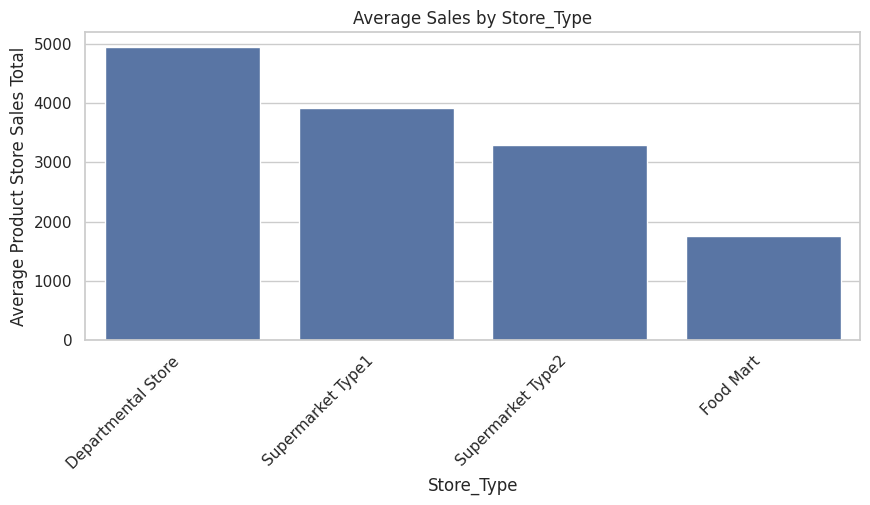

In [ ]:
# Average sales by categorical features
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    avg_sales = df.groupby(col)["Product_Store_Sales_Total"].mean().sort_values(ascending=False)
    sns.barplot(x=avg_sales.index, y=avg_sales.values)
    plt.title(f"Average Sales by {col}")
    plt.ylabel("Average Product Store Sales Total")
    plt.xticks(rotation=45, ha="right")
    plt.show()

### Code explanation and observations

**What this code does**
- Calculates average sales for each category in every categorical feature.
- Sorts the categories by average sales and visualizes them using bar plots.

**Observations**
- Store-related variables show strong separation in average sales.
- `Departmental Store`, `Tier 1`, and `OUT003` have the highest average sales.
- `Food Mart`, `Tier 3`, and `OUT002` have the lowest average sales.
- Product type and sugar content have smaller but still useful differences across categories.
- These patterns support keeping categorical store attributes in the model.

### EDA observations

- `Product_MRP` is one of the strongest sales drivers and has a strong positive relationship with `Product_Store_Sales_Total`.
- `Product_Weight` also has a strong positive correlation with sales.
- Store-level variables have meaningful differences in average sales:
  - Departmental stores perform best on average.
  - Food marts have the lowest average sales.
  - Tier 1 locations have higher average sales than Tier 2 and Tier 3 locations.
- `Product_Allocated_Area` is right-skewed and has weak linear correlation with sales, but it may still contribute through non-linear interactions.
- Some outliers exist, but they appear to be valid business observations rather than data errors.
- Tree-based models are appropriate because they can learn non-linear patterns and interactions between pricing, product, and store attributes.

# **Data Preprocessing**

In [ ]:
# Standardize inconsistent category labels
df["Product_Sugar_Content"] = df["Product_Sugar_Content"].replace({"reg": "Regular"})

# Feature engineering
REFERENCE_YEAR = 2025

def preprocess_superkart(raw_df):
    """Apply deterministic feature engineering used for both training and deployment."""
    data = raw_df.copy()
    data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace({"reg": "Regular"})

    # Product_Id starts with FD, DR, or NC. Convert this prefix into a business-friendly category.
    data["Product_Category"] = (
        data["Product_Id"].astype(str).str[:2]
        .map({"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"})
        .fillna("Other")
    )

    # Convert establishment year into store age
    data["Store_Age"] = REFERENCE_YEAR - data["Store_Establishment_Year"].astype(int)

    return data

processed_df = preprocess_superkart(df)

target = "Product_Store_Sales_Total"

numeric_features = [
    "Product_Weight",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Age"
]

categorical_features = [
    "Product_Sugar_Content",
    "Product_Type",
    "Store_Id",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Category"
]

feature_columns = numeric_features + categorical_features
raw_feature_columns = [col for col in df.columns if col != target]

X = processed_df[feature_columns]
y = processed_df[target]

X.head()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Age,Product_Sugar_Content,Product_Type,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Category
0,12.66,0.027,117.08,16,Low Sugar,Frozen Foods,OUT004,Medium,Tier 2,Supermarket Type2,Food
1,16.54,0.144,171.43,26,Low Sugar,Dairy,OUT003,Medium,Tier 1,Departmental Store,Food
2,14.28,0.031,162.08,38,Regular,Canned,OUT001,High,Tier 2,Supermarket Type1,Food
3,12.10,0.112,186.31,38,Low Sugar,Baking Goods,OUT001,High,Tier 2,Supermarket Type1,Food
4,9.57,0.010,123.67,27,No Sugar,Health and Hygiene,OUT002,Small,Tier 3,Food Mart,Non-Consumable


### Code explanation and observations

**What this code does**
- Standardizes inconsistent values in `Product_Sugar_Content` by replacing `reg` with `Regular`.
- Creates a reusable preprocessing function for both training and deployment.
- Extracts `Product_Category` from the first two characters of `Product_Id`: `FD` = Food, `DR` = Drinks, and `NC` = Non-Consumable.
- Converts `Store_Establishment_Year` into `Store_Age` using reference year 2025.
- Defines the target variable, numerical features, categorical features, and final feature matrix.

**Observations**
- `Product_Id` itself is too unique to use directly, but its prefix contains meaningful product-category information.
- `Store_Age` is easier for the model to learn from than the raw establishment year.
- The final feature set combines product, price, store, and engineered features.
- The same preprocessing logic is stored later with the model so backend predictions use the exact same transformations as training.

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (7010, 11)
Testing set: (1753, 11)


### Code explanation and observations

**What this code does**
- Splits the data into training and testing sets.
- Uses **80%** of the data for training and **20%** for testing.
- Uses a fixed random state so the split is reproducible.

**Observations**
- Training set has **7,010 rows**.
- Testing set has **1,753 rows**.
- The test set is kept separate and is used to estimate how well the model performs on unseen data.

In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Product_Weight', 'Product_Allocated_Area',
                                  'Product_MRP', 'Store_Age']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Product_Sugar_Content', 'Product_Type',
                                  'Store_Id', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type',
                                  'Product_Category'])])

### Code explanation and observations

**What this code does**
- Builds a preprocessing pipeline using `ColumnTransformer`.
- Applies `StandardScaler` to numerical features.
- Applies `OneHotEncoder` to categorical features.
- Uses `handle_unknown='ignore'` so the model can handle new categories during prediction without failing.

**Observations**
- Numerical and categorical columns require different preprocessing steps.
- Using `ColumnTransformer` ensures the transformations are applied consistently during training and prediction.
- Wrapping this preprocessor inside a model pipeline reduces deployment risk because preprocessing and prediction are saved together.

# **Model Building**

## Define functions for Model Evaluation

In [ ]:
# Function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# Function to compute regression metrics
def model_performance_regression(model, predictors, target):
    """Evaluate a regression model using RMSE, MAE, R2, adjusted R2, and MAPE."""
    pred = model.predict(predictors)

    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    r2 = r2_score(target, pred)
    adjr2 = adj_r2_score(predictors, target, pred)
    mape = mean_absolute_percentage_error(target, pred)

    return pd.Series(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        }
    )


def fit_and_evaluate_model(model_name, estimator):
    """Create pipeline, fit model, and return train/test metrics."""
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    pipeline.fit(X_train, y_train)

    train_perf = model_performance_regression(pipeline, X_train, y_train)
    test_perf = model_performance_regression(pipeline, X_test, y_test)

    return pipeline, train_perf, test_perf

### Code explanation and observations

**What this code does**
- Defines a function to calculate Adjusted R-squared.
- Defines a reusable function to calculate RMSE, MAE, R-squared, Adjusted R-squared, and MAPE.
- Defines a helper function that builds a pipeline, fits the model, and returns both training and testing metrics.

**Observations**
- These functions avoid repeating evaluation code for every model.
- RMSE and MAE measure prediction error; lower values are better.
- R-squared and Adjusted R-squared measure explanatory power; higher values are better.
- MAPE gives average percentage error; lower values are better.
- Evaluating both training and testing performance helps detect overfitting.

The ML models built below are:

1. Random Forest
2. XGBoost

Both models are appropriate for non-linear regression problems and can work well with mixed numerical and categorical data after preprocessing.

In [ ]:
# Base models
rf_estimator = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_estimator = XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models = {
    "Random Forest Estimator": rf_estimator,
    "XGBoost": xgb_estimator,
}

trained_models = {}
train_results = {}
test_results = {}

for name, estimator in models.items():
    print(f"Training {name}...")
    trained_model, train_perf, test_perf = fit_and_evaluate_model(name, estimator)

    trained_models[name] = trained_model
    train_results[name] = train_perf
    test_results[name] = test_perf

print("Model training completed.")

Training Random Forest Estimator...
Training XGBoost...
Model training completed.


### Code explanation and observations

**What this code does**
- Defines two baseline models: Random Forest Regressor and XGBoost Regressor.
- Trains each model using the same preprocessing and evaluation pipeline.
- Stores trained models and their train/test metrics for comparison.

**Observations**
- Both models trained successfully.
- Random Forest and XGBoost are good choices for this problem because they can capture non-linear relationships and interactions among product and store features.
- The same pipeline is used for both models, so their performance comparison is fair.

In [ ]:
# Training performance comparison
training_performance = pd.DataFrame(train_results)
training_performance

,Random Forest Estimator,XGBoost
RMSE,106.313355,261.034012
MAE,39.887777,110.522822
R-squared,0.990033,0.939915
Adj. R-squared,0.990018,0.939821
MAPE,0.014980,0.042526


### Code explanation and observations

**What this code does**
- Converts the training metrics dictionary into a comparison table.
- Shows how each baseline model performs on the training data.

**Observations**
- Random Forest has much stronger training performance than XGBoost.
- Random Forest training R-squared is about **0.990**, while XGBoost training R-squared is about **0.940**.
- Random Forest training RMSE is about **106**, much lower than XGBoost training RMSE of about **261**.
- Very high training performance can be a sign that the model is fitting the training data very closely, so test performance must be checked before selecting the model.

In [ ]:
# Testing performance comparison
testing_performance = pd.DataFrame(test_results)
testing_performance

,Random Forest Estimator,XGBoost
RMSE,283.695311,294.929074
MAE,108.647420,127.709914
R-squared,0.929464,0.923767
Adj. R-squared,0.929018,0.923286
MAPE,0.038888,0.046645


### Code explanation and observations

**What this code does**
- Converts the testing metrics dictionary into a comparison table.
- Shows how each baseline model performs on unseen test data.

**Observations**
- Random Forest performs slightly better than XGBoost on the test set.
- Random Forest test RMSE is about **284**, compared with XGBoost test RMSE of about **295**.
- Random Forest test R-squared is about **0.929**, compared with XGBoost test R-squared of about **0.924**.
- The gap between Random Forest train and test performance indicates some overfitting, but the model still generalizes well overall.

# **Model Performance Improvement - Hyperparameter Tuning**

In [ ]:
# Tuned Random Forest
rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Tuned XGBoost
xgb_tuned = XGBRegressor(
    n_estimators=350,
    learning_rate=0.04,
    max_depth=3,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.5,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

tuned_models = {
    "Random Forest Tuned": rf_tuned,
    "XGBoost Tuned": xgb_tuned,
}

for name, estimator in tuned_models.items():
    print(f"Training {name}...")
    trained_model, train_perf, test_perf = fit_and_evaluate_model(name, estimator)

    trained_models[name] = trained_model
    train_results[name] = train_perf
    test_results[name] = test_perf

print("Tuned model training completed.")

Training Random Forest Tuned...
Training XGBoost Tuned...
Tuned model training completed.


### Code explanation and observations

**What this code does**
- Defines tuned versions of Random Forest and XGBoost.
- Random Forest is regularized using parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf`.
- XGBoost is tuned using parameters such as lower tree depth, learning rate, child weight, subsampling, column sampling, and L2 regularization.
- Trains and evaluates the tuned models using the same helper function.

**Observations**
- Hyperparameter tuning is used to reduce overfitting and improve generalization.
- Tuned Random Forest becomes less complex than the baseline Random Forest.
- Tuned XGBoost is also regularized, but in this run it does not outperform the Random Forest models on the test data.

In [ ]:
# Combined training performance comparison
training_performance = pd.DataFrame(train_results)
training_performance

,Random Forest Estimator,XGBoost,Random Forest Tuned,XGBoost Tuned
RMSE,106.313355,261.034012,190.090437,292.490524
MAE,39.887777,110.522822,72.518013,129.366605
R-squared,0.990033,0.939915,0.968137,0.924561
Adj. R-squared,0.990018,0.939821,0.968087,0.924443
MAPE,0.014980,0.042526,0.026514,0.050826


### Code explanation and observations

**What this code does**
- Combines training metrics for all baseline and tuned models.
- Allows comparison of how closely each model fits the training data.

**Observations**
- Baseline Random Forest has the best training score with R-squared about **0.990**, which suggests it fits the training data very closely.
- Tuned Random Forest has lower training R-squared of about **0.968**, which is expected because tuning added regularization.
- XGBoost and tuned XGBoost have lower training performance than Random Forest models.
- Lower training performance is not always bad if it improves test performance and reduces overfitting.

In [ ]:
# Combined testing performance comparison
testing_performance = pd.DataFrame(test_results)
testing_performance

,Random Forest Estimator,XGBoost,Random Forest Tuned,XGBoost Tuned
RMSE,283.695311,294.929074,277.101755,307.531403
MAE,108.647420,127.709914,108.933089,138.301562
R-squared,0.929464,0.923767,0.932705,0.917113
Adj. R-squared,0.929018,0.923286,0.932279,0.916589
MAPE,0.038888,0.046645,0.038833,0.050392


### Code explanation and observations

**What this code does**
- Combines testing metrics for all baseline and tuned models.
- This table is the most important model-selection table because it shows performance on unseen data.

**Observations**
- **Random Forest Tuned** has the best test RMSE at about **277.10**.
- **Random Forest Tuned** also has the best test R-squared at about **0.933**.
- Baseline Random Forest is close, but its RMSE is slightly higher at about **283.70**.
- XGBoost and tuned XGBoost perform worse than Random Forest on this dataset.
- Based on test performance, Random Forest Tuned is the strongest candidate for final deployment.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [ ]:
# Select final model based on the lowest test RMSE
final_model_name = testing_performance.loc["RMSE"].idxmin()
final_model = trained_models[final_model_name]

print("Final selected model:", final_model_name)
testing_performance[[final_model_name]]

Final selected model: Random Forest Tuned


,Random Forest Tuned
RMSE,277.101755
MAE,108.933089
R-squared,0.932705
Adj. R-squared,0.932279
MAPE,0.038833


### Code explanation and observations

**What this code does**
- Selects the final model automatically by finding the model with the lowest test RMSE.
- Retrieves the trained pipeline corresponding to that model.
- Displays the selected model and its test metrics.

**Observations**
- The final selected model is **Random Forest Tuned**.
- It has the lowest test RMSE, about **277.10**.
- Its test MAE is about **108.93**, meaning average absolute prediction error is around 109 sales units.
- Its test R-squared is about **0.933**, meaning the model explains about 93.3% of variation in test sales.
- Its test MAPE is about **3.88%**, which is a strong percentage-error result for this use case.

In [ ]:
# Compare train and test metrics side-by-side for the final model
final_comparison = pd.DataFrame({
    "Training": training_performance[final_model_name],
    "Testing": testing_performance[final_model_name],
})
final_comparison

,Training,Testing
RMSE,190.090437,277.101755
MAE,72.518013,108.933089
R-squared,0.968137,0.932705
Adj. R-squared,0.968087,0.932279
MAPE,0.026514,0.038833


### Code explanation and observations

**What this code does**
- Compares training and testing metrics side by side for the final selected model.
- Helps assess whether the final model is overfitting or generalizing well.

**Observations**
- Training R-squared is about **0.968**, and testing R-squared is about **0.933**.
- Training RMSE is about **190**, while testing RMSE is about **277**.
- The model performs better on training data than testing data, which is expected.
- The train-test gap is present but acceptable for a strong tree-based model.
- The tuned model is a better deployment choice than the baseline Random Forest because it reduces overfitting while achieving the best test RMSE.

### Final model selection rationale

The final model is selected primarily using **test performance** because the test set represents unseen data.

- The **Random Forest Tuned** model has the lowest test RMSE, about **277.10**.
- It also has the best test R-squared, about **0.933**.
- The baseline Random Forest has slightly lower training error, but it shows more overfitting.
- The tuned Random Forest reduces overfitting while still producing the best test-set accuracy.
- XGBoost models did not outperform Random Forest for this dataset.
- Therefore, **Random Forest Tuned** is selected as the final model for serialization and deployment.

In [ ]:
# Create backend folder and serialize final model bundle
os.makedirs("backend_files", exist_ok=True)

model_bundle = {
    "model": final_model,
    "raw_feature_columns": raw_feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "reference_year": REFERENCE_YEAR,
    "target": target,
    "final_model_name": final_model_name,
}

model_path = "backend_files/superkart_sales_prediction_model_v1_0.joblib"
joblib.dump(model_bundle, model_path)

print(f"Saved final model bundle to {model_path}")

Saved final model bundle to backend_files/superkart_sales_prediction_model_v1_0.joblib


### Code explanation and observations

**What this code does**
- Creates the `backend_files` folder.
- Packages the final trained model pipeline along with important metadata.
- Saves the model bundle as a `.joblib` file for backend deployment.

**Observations**
- The saved bundle includes the model, raw feature columns, numerical and categorical feature names, reference year, target name, and final model name.
- Saving metadata with the model is important because the backend must validate input columns and apply the same feature engineering as the notebook.
- The model file was saved successfully to `backend_files/superkart_sales_prediction_model_v1_0.joblib`.

In [ ]:
# Create a sample batch input file for backend testing
sample_batch = df.drop(columns=[target]).head(10)
sample_batch.to_csv("backend_files/superkart_batch_input_sample.csv", index=False)

sample_batch.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart


### Code explanation and observations

**What this code does**
- Creates a sample batch input CSV using the first 10 rows of the dataset.
- Removes the target column because deployed applications should receive only input features.
- Saves the sample file inside the backend folder.

**Observations**
- The generated CSV is useful for testing batch prediction in the frontend or backend API.
- The sample file contains raw input columns in the same format expected by the deployed service.
- This avoids accidentally sending the target column during prediction.

# **Deployment - Backend**

## Flask Web Framework

In [ ]:
%%writefile backend_files/app.py
import os
import joblib
import pandas as pd
from flask import Flask, request, jsonify

MODEL_PATH = os.getenv("MODEL_PATH", "superkart_sales_prediction_model_v1_0.joblib")
bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
raw_feature_columns = bundle["raw_feature_columns"]
numeric_features = bundle["numeric_features"]
categorical_features = bundle["categorical_features"]
reference_year = bundle["reference_year"]

app = Flask(__name__)

def prepare_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Apply the same feature engineering used during training."""
    data = raw_df.copy()

    missing = [col for col in raw_feature_columns if col not in data.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data["Product_Sugar_Content"] = data["Product_Sugar_Content"].replace({"reg": "Regular"})
    data["Product_Category"] = (
        data["Product_Id"].astype(str).str[:2]
        .map({"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"})
        .fillna("Other")
    )
    data["Store_Age"] = reference_year - data["Store_Establishment_Year"].astype(int)

    return data[numeric_features + categorical_features]

@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "message": "SuperKart Sales Prediction API is running.",
        "endpoints": {
            "single_prediction": "/predict",
            "batch_prediction": "/predict_file"
        }
    })

@app.route("/predict", methods=["POST"])
def predict():
    try:
        input_json = request.get_json(force=True)
        raw_df = pd.DataFrame([input_json])
        features = prepare_features(raw_df)
        prediction = float(model.predict(features)[0])
        return jsonify({"prediction": round(prediction, 2)})
    except Exception as exc:
        return jsonify({"error": str(exc)}), 400

@app.route("/predict_file", methods=["POST"])
def predict_file():
    try:
        if "file" not in request.files:
            return jsonify({"error": "Please upload a CSV file using the form field named 'file'."}), 400

        file = request.files["file"]
        raw_df = pd.read_csv(file)
        features = prepare_features(raw_df)
        predictions = model.predict(features)

        output = raw_df.copy()
        output["Predicted_Product_Store_Sales_Total"] = predictions.round(2)

        return output.to_json(orient="records")
    except Exception as exc:
        return jsonify({"error": str(exc)}), 400

if __name__ == "__main__":
    port = int(os.getenv("PORT", 7860))
    app.run(host="0.0.0.0", port=port)

Writing backend_files/app.py


### Code explanation and observations

**What this code does**
- Writes the backend Flask application to `backend_files/app.py`.
- Loads the saved model bundle.
- Defines preprocessing logic for incoming raw input.
- Provides `/health`, `/predict`, and `/predict_file` endpoints.
- Supports both single JSON prediction and batch CSV prediction.

**Observations**
- The backend mirrors the notebook preprocessing steps, including sugar-content cleanup, product-category extraction, and store-age creation.
- `/predict` is used by the frontend single-prediction form.
- `/predict_file` is used by the frontend batch CSV upload.
- This separation makes the backend reusable for both interactive and batch inference.

## Dependencies File

In [ ]:
%%writefile backend_files/requirements.txt
flask==3.0.3
gunicorn==22.0.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4

Writing backend_files/requirements.txt


### Code explanation and observations

**What this code does**
- Writes the backend `requirements.txt` file.
- Lists the Python packages needed by the Flask backend Space.

**Observations**
- The backend dependencies include Flask, Gunicorn, pandas, NumPy, scikit-learn, joblib, and XGBoost.
- These dependencies are required because the deployed model pipeline uses preprocessing and model objects from these libraries.
- Keeping this file minimal helps the Hugging Face Space build faster.

## Dockerfile

In [ ]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

WORKDIR /app
COPY . .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 7860

CMD ["gunicorn", "-b", "0.0.0.0:7860", "app:app"]

Writing backend_files/Dockerfile


### Code explanation and observations

**What this code does**
- Writes the backend Dockerfile.
- Uses a Python slim base image.
- Copies backend files into the container, installs requirements, exposes port 7860, and starts the Flask app with Gunicorn.

**Observations**
- Hugging Face Docker Spaces expect the app to serve traffic on port **7860**.
- Gunicorn is used instead of Flask’s development server because it is more appropriate for deployment.
- This Dockerfile makes the backend reproducible in Hugging Face Spaces.

## Setting up a Hugging Face Docker Space for the Backend

In [ ]:
# Hugging Face backend configuration
backend_repo_id = "gnkishore/SuperKart-Backend"

# Use an environment variable when available, otherwise securely prompt for the token.
hf_token = os.getenv("HF_TOKEN")
if not hf_token:
    hf_token = getpass("Enter your Hugging Face write token: ")

login(token=hf_token)
api = HfApi(token=hf_token)

# Create the backend Space if it does not already exist.
# If the Space already exists, exist_ok=True avoids failure.
api.create_repo(
    repo_id=backend_repo_id,
    repo_type="space",
    space_sdk="docker",
    private=False,
    exist_ok=True,
)

print("Backend Space is ready:", backend_repo_id)

Enter your Hugging Face write token: ··········
Backend Space is ready: gnkishore/SuperKart-Backend


### Code explanation and observations

**What this code does**
- Configures the Hugging Face backend repository ID.
- Reads a Hugging Face token securely from the environment or prompts for it.
- Uses the Hugging Face API to create or access the backend Docker Space.

**Observations**
- The backend Space is configured as `gnkishore/SuperKart-Backend`.
- The notebook avoids hard-coding the Hugging Face token, which is the correct security practice.
- Successful execution means the backend Space is ready to receive the uploaded backend files.

## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
# Upload backend model, Flask app, requirements, Dockerfile, and sample batch input
api.upload_folder(
    folder_path="backend_files",
    repo_id=backend_repo_id,
    repo_type="space",
)

print("Backend files uploaded successfully.")
print("Backend URL: https://gnkishore-superkart-backend.hf.space")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ..._sales_prediction_model_v1_0.joblib:   3%|3         | 1.03MB / 30.0MB            

Backend files uploaded successfully.
Backend URL: https://gnkishore-superkart-backend.hf.space


### Code explanation and observations

**What this code does**
- Uploads the complete `backend_files` folder to the Hugging Face backend Space.
- This includes the Flask app, model file, requirements file, Dockerfile, and sample input file.

**Observations**
- Uploading these files triggers the Hugging Face Space build process.
- After the build completes, the backend exposes prediction APIs.
- The backend URL is later used by the frontend app and API testing cells.

# **Deployment - Frontend**

## Points to note before executing the below cells

- Create or reuse the Hugging Face frontend Space `gnkishore/SuperKart-Frontend`.
- The frontend calls the backend API endpoint hosted at `https://gnkishore-superkart-backend.hf.space/predict`.
- If your backend Space URL changes, update the `DEFAULT_BACKEND_URL` in the Streamlit app or configure `BACKEND_URL` as a Space secret.

## Streamlit for Interactive UI

In [ ]:
os.makedirs("frontend_files", exist_ok=True)

### Code explanation and observations

**What this code does**
- Creates the `frontend_files` folder if it does not already exist.

**Observations**
- This prepares a clean location for Streamlit frontend files.
- The frontend app, dependencies file, and Dockerfile are written into this folder in the following cells.

In [ ]:
%%writefile frontend_files/app.py
import os
import requests
import pandas as pd
import streamlit as st

DEFAULT_BACKEND_URL = "https://gnkishore-superkart-backend.hf.space/predict"
DEFAULT_BATCH_URL = "https://gnkishore-superkart-backend.hf.space/predict_file"

backend_url = DEFAULT_BACKEND_URL
batch_url = DEFAULT_BATCH_URL

st.set_page_config(page_title="SuperKart Sales Predictor", page_icon="🛒", layout="wide")

st.title("🛒 SuperKart Sales Prediction")
st.write("Estimate product-store sales using product, store, and pricing details.")

with st.sidebar:
    st.header("Backend")
    st.write("API endpoint:")
    st.code(backend_url)

tab1, tab2 = st.tabs(["Single prediction", "Batch CSV prediction"])

with tab1:
    st.subheader("Enter product and store details")

    col1, col2, col3 = st.columns(3)

    with col1:
        product_id = st.text_input("Product Id", value="FD6114")
        product_weight = st.number_input("Product Weight", min_value=0.0, value=12.66, step=0.01)
        product_sugar_content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
        product_allocated_area = st.number_input("Product Allocated Area", min_value=0.0, value=0.05, step=0.001, format="%.3f")

    with col2:
        product_type = st.selectbox(
            "Product Type",
            [
                "Frozen Foods", "Dairy", "Canned", "Baking Goods", "Health and Hygiene",
                "Snack Foods", "Meat", "Household", "Hard Drinks", "Fruits and Vegetables",
                "Breads", "Soft Drinks", "Breakfast", "Others", "Starchy Foods", "Seafood"
            ]
        )
        product_mrp = st.number_input("Product MRP", min_value=0.0, value=150.0, step=0.01)
        store_id = st.selectbox("Store Id", ["OUT001", "OUT002", "OUT003", "OUT004"])
        store_establishment_year = st.number_input("Store Establishment Year", min_value=1900, max_value=2026, value=2009, step=1)

    with col3:
        store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
        store_location_city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
        store_type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])

    payload = {
        "Product_Id": product_id,
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar_content,
        "Product_Allocated_Area": product_allocated_area,
        "Product_Type": product_type,
        "Product_MRP": product_mrp,
        "Store_Id": store_id,
        "Store_Establishment_Year": store_establishment_year,
        "Store_Size": store_size,
        "Store_Location_City_Type": store_location_city_type,
        "Store_Type": store_type,
    }

    if st.button("Predict sales", type="primary"):
        try:
            response = requests.post(backend_url, json=payload, timeout=30)
            if response.status_code == 200:
                result = response.json()
                st.success(f"Predicted Product Store Sales Total: {result['prediction']:,.2f}")
            else:
                st.error(response.text)
        except Exception as exc:
            st.error(f"Could not connect to backend: {exc}")

with tab2:
    st.subheader("Upload a CSV file for batch predictions")
    st.write("The CSV should contain the same raw feature columns used in training, excluding the target column.")
    uploaded_file = st.file_uploader("Upload CSV", type=["csv"])

    if uploaded_file is not None:
        input_df = pd.read_csv(uploaded_file)
        st.write("Preview of uploaded data:")
        st.dataframe(input_df.head())

        if st.button("Run batch prediction"):
            try:
                files = {"file": input_df.to_csv(index=False).encode("utf-8")}
                response = requests.post(batch_url, files=files, timeout=60)
                if response.status_code == 200:
                    pred_df = pd.read_json(response.text)
                    st.success("Batch prediction completed.")
                    st.dataframe(pred_df)
                    st.download_button(
                        "Download predictions as CSV",
                        data=pred_df.to_csv(index=False).encode("utf-8"),
                        file_name="superkart_predictions.csv",
                        mime="text/csv",
                    )
                else:
                    st.error(response.text)
            except Exception as exc:
                st.error(f"Batch prediction failed: {exc}")

Overwriting frontend_files/app.py


### Code explanation and observations

**What this code does**
- Writes the Streamlit frontend application to `frontend_files/app.py`.
- Defines a single-prediction form for product and store details.
- Defines a batch CSV upload tab for multiple predictions.
- Sends single prediction requests to the backend `/predict` endpoint.
- Sends batch CSV requests to the backend `/predict_file` endpoint.
- Displays predictions and allows downloading batch results as CSV.

**Observations**
- The frontend is a user-friendly interface over the backend model API.
- It does not load the model directly; it calls the backend service.
- This design keeps model inference centralized in the backend and makes the frontend lightweight.
- The app uses the deployed backend URL for `gnkishore/SuperKart-Backend`.

## Dependencies File

In [ ]:
%%writefile frontend_files/requirements.txt
streamlit==1.43.2
requests==2.32.4
pandas==2.2.2
numpy==2.0.2

Overwriting frontend_files/requirements.txt


### Code explanation and observations

**What this code does**
- Writes the frontend `requirements.txt` file.
- Lists the packages needed to run the Streamlit frontend.

**Observations**
- The frontend only needs Streamlit, requests, pandas, and NumPy.
- It does not need scikit-learn or XGBoost because predictions are handled by the backend.
- This keeps the frontend Space smaller and faster to build.

## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile
FROM python:3.9-slim

WORKDIR /app
COPY . .

RUN pip install --no-cache-dir -r requirements.txt


CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]


Overwriting frontend_files/Dockerfile


### Code explanation and observations

**What this code does**
- Writes the frontend Dockerfile.
- Uses a Python slim base image.
- Copies frontend files, installs dependencies, and starts the Streamlit app on port 7860.

**Observations**
- Hugging Face Spaces require the app to listen on port **8501**.
- The Dockerfile runs Streamlit with the correct address and port configuration.
- This allows the frontend Space to serve the UI publicly after deployment.

## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
# Hugging Face frontend configuration
frontend_repo_id = "gnkishore/SuperKart-Frontend"

# Reuse hf_token if already available, otherwise securely prompt for it.
try:
    hf_token
except NameError:
    hf_token = os.getenv("HF_TOKEN") or getpass("Enter your Hugging Face write token: ")

login(token=hf_token)
api = HfApi(token=hf_token)

# Create the frontend Space if it does not already exist.
api.create_repo(
    repo_id=frontend_repo_id,
    repo_type="space",
    space_sdk="docker",
    private=False,
    exist_ok=True,
)

# Upload Streamlit app, requirements, and Dockerfile
api.upload_folder(
    folder_path="frontend_files",
    repo_id=frontend_repo_id,
    repo_type="space",
)

print("Frontend files uploaded successfully.")
print("Frontend URL: https://gnkishore-superkart-frontend.hf.space")

Frontend files uploaded successfully.
Frontend URL: https://gnkishore-superkart-frontend.hf.space


### Code explanation and observations

**What this code does**
- Configures the Hugging Face frontend repository ID.
- Creates or accesses the frontend Docker Space.
- Uploads the frontend app, requirements file, and Dockerfile.

**Observations**
- The frontend Space is configured as `gnkishore/SuperKart-Frontend`.
- Successful upload means Hugging Face can build and serve the Streamlit UI.
- Once the frontend build completes, users can test both single prediction and batch prediction from the browser.

# **Backend API Testing**

In [ ]:
# Test backend single prediction after deployment
model_url = "https://gnkishore-superkart-backend.hf.space/predict"

sample_payload = df.drop(columns=[target]).iloc[0].to_dict()

response = requests.post(model_url, json=sample_payload)
print("Status code:", response.status_code)
print("Response:", response.text)

Status code: 200
Response: {"prediction":2896.46}



### Code explanation and observations

**What this code does**
- Sends a sample JSON payload to the deployed backend `/predict` endpoint.
- Prints the HTTP status code and backend response.

**Observations**
- The status code is **200**, which means the backend API request succeeded.
- The sample response returns a prediction of about **2,896.46**.
- This confirms that the deployed backend can accept input, preprocess it, run the model, and return a prediction.

In [ ]:
# Test backend batch prediction after deployment
model_batch_url = "https://gnkishore-superkart-backend.hf.space/predict_file"

batch_input_data = df.drop(columns=[target]).head(5)
batch_input = {
    "file": batch_input_data.to_csv(header=True, index=False).encode("utf-8")
}

response = requests.post(model_batch_url, files=batch_input)
print("Status code:", response.status_code)
print("Response:", response.text[:1000])

Status code: 200
Response: [{"Product_Id":"FD6114","Product_Weight":12.66,"Product_Sugar_Content":"Low Sugar","Product_Allocated_Area":0.027,"Product_Type":"Frozen Foods","Product_MRP":117.08,"Store_Id":"OUT004","Store_Establishment_Year":2009,"Store_Size":"Medium","Store_Location_City_Type":"Tier 2","Store_Type":"Supermarket Type2","Predicted_Product_Store_Sales_Total":2896.46},{"Product_Id":"FD7839","Product_Weight":16.54,"Product_Sugar_Content":"Low Sugar","Product_Allocated_Area":0.144,"Product_Type":"Dairy","Product_MRP":171.43,"Store_Id":"OUT003","Store_Establishment_Year":1999,"Store_Size":"Medium","Store_Location_City_Type":"Tier 1","Store_Type":"Departmental Store","Predicted_Product_Store_Sales_Total":4833.84},{"Product_Id":"FD5075","Product_Weight":14.28,"Product_Sugar_Content":"Regular","Product_Allocated_Area":0.031,"Product_Type":"Canned","Product_MRP":162.08,"Store_Id":"OUT001","Store_Establishment_Year":1987,"Store_Size":"High","Store_Location_City_Type":"Tier 2","Store

### Code explanation and observations

**What this code does**
- Creates a small batch input dataset from raw feature columns.
- Sends the CSV file to the deployed backend `/predict_file` endpoint.
- Prints the HTTP status code and returned predictions.

**Observations**
- The status code is **200**, so batch inference is working.
- The response contains the input rows along with predicted sales values.
- This confirms that the backend supports CSV-based batch prediction, which is required for the frontend batch-upload feature.

# **Actionable Insights and Business Recommendations**

# **Actionable Insights and Business Recommendations**

- Product pricing is a major driver of sales. Products with higher `Product_MRP` tend to generate higher total sales.
- Store characteristics are highly important. Store type, city tier, and store size should be used when planning inventory allocation.
- Departmental stores and Tier 1 locations show stronger sales potential, so high-demand products can be prioritized there.
- Food marts and Tier 3 locations show lower average sales, so inventory planning should be more conservative in those stores.
- The final **Random Forest Tuned** model can be used to forecast sales for new product-store combinations before inventory decisions are made.
- Business teams can use the frontend app for quick one-off predictions and batch CSV predictions.
- The backend API makes the model reusable by other applications, dashboards, or automated planning workflows.



<font size=6 color='blue'>Power Ahead!</font>
___